In [ ]:
# SimPEG functionality
from simpeg.potential_fields import gravity
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

mpl.rcParams.update({"font.size": 14})

## Topography

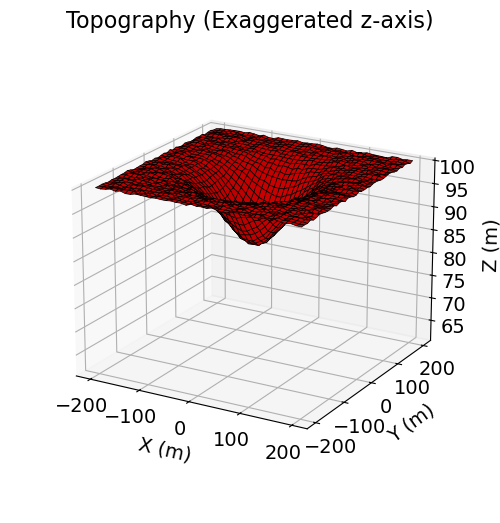

In [2]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-200, 200, 41), np.linspace(-200, 200, 41))

rng = np.random.default_rng(seed=737)
z_topo = (
    -15 * np.exp(-(x_topo**2 + y_topo**2) / 80**2)
    + 100.0
    + rng.uniform(low=0.0, high=0.5, size=x_topo.shape)
)


fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([z_topo.max() - 40, z_topo.max()])
ax.plot_surface(x_topo, y_topo, z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

## Survey

In [3]:
# Define the observation locations as an (N, 3) numpy array or load them from a file.
x = np.linspace(-80.0, 80.0, 17) #−80,−70,−60,…,70,80
y = np.linspace(-80.0, 80.0, 17)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T) # 把矩阵拉平成列向量风格的一维数组
fun_interp = LinearNDInterpolator(np.c_[mkvc(x_topo), mkvc(y_topo)], mkvc(z_topo)) #根据已有 topography 数据，建立一个地表高程插值函数。
z = fun_interp(np.c_[x, y]) + 5.0
receiver_locations = np.c_[x, y, z]

In [4]:
# Define the component(s) of the field we want to simulate as strings within
# a list. Here we simulate only the vertical component of the gravity anomaly.
components = ["gz"]

# Use the observation locations and components to define receivers for the entire survey
# in one step. The set of receivers, even if it's only 1, are organized within a list.
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]

# Defining the source. For gravity surveys, we simply need to specific the list of
# receivers associated with the source field.
source_field = gravity.sources.SourceField(receiver_list=receiver_list)

# Defining the survey.
survey = gravity.survey.Survey(source_field)

In [5]:
print("# of data: {}".format(survey.nD))  # number of data that will be simulated
print(survey.source_field)  # the source field object
print(survey.source_field.receiver_list[0])  # the receiver object
print(receiver_list[0].locations[:5, :])  # the first 5 receiver locations

# of data: 289
[[-80.         -80.         103.45749978]
 [-70.         -80.         102.92439828]
 [-60.         -80.         102.04004226]
 [-50.         -80.         101.42653248]
 [-40.         -80.         100.7063376 ]]


## Mesh

In [6]:
# Generate tensor mesh with top at z = 0 m
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)] #网格在中心密集，向边界逐渐疏
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
mesh.origin += np.r_[0.0, 0.0, z_topo.max()]

In [7]:
print("# of cells: {}".format(mesh.n_cells))  # Number of cells
print("# of x-faces: {}".format(mesh.n_faces_x))  # Number of x-faces
print("Origin: {}".format(mesh.origin))  # bottom-southewest corner
print("Max cell volume: {}".format(mesh.cell_volumes.max()))  # Largest cell size
print(mesh.cell_centers[0:5, :])  # Cell center locations

# of cells: 50000
# of x-faces: 51000
Origin: [-158.78015    -158.78015     -33.28281358]
Max cell volume: 6398.236626761349
[[-149.497825   -149.497825    -24.00048858]
 [-133.07525    -149.497825    -24.00048858]
 [-120.4425     -149.497825    -24.00048858]
 [-110.725      -149.497825    -24.00048858]
 [-103.25       -149.497825    -24.00048858]]


## Active Cells

In [8]:
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]

# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

# Define mapping from model to active cells. The model consists of a density
# contrast value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active)

## Model

In [9]:
# Define density contrast values for each unit in g/cc
background_density = 0.0
block_density = -0.2
sphere_density = 0.2

# Instantiate a vector array.
model = background_density * np.ones(n_active)

# You could find the indicies of specific cells within the model and change their
# values to add structures.
ind_block = (
    (mesh.cell_centers[active_cells, 0] > -50.0)
    & (mesh.cell_centers[active_cells, 0] < -20.0)
    & (mesh.cell_centers[active_cells, 1] > -15.0)
    & (mesh.cell_centers[active_cells, 1] < 15.0)
    & (mesh.cell_centers[active_cells, 2] > 50.0)
    & (mesh.cell_centers[active_cells, 2] < 70.0)
)
model[ind_block] = block_density

# You can also use SimPEG utilities to add structures to the model more concisely
ind_sphere = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, 60.0], 14.0, mesh.cell_centers
)
ind_sphere = ind_sphere[active_cells]
model[ind_sphere] = sphere_density


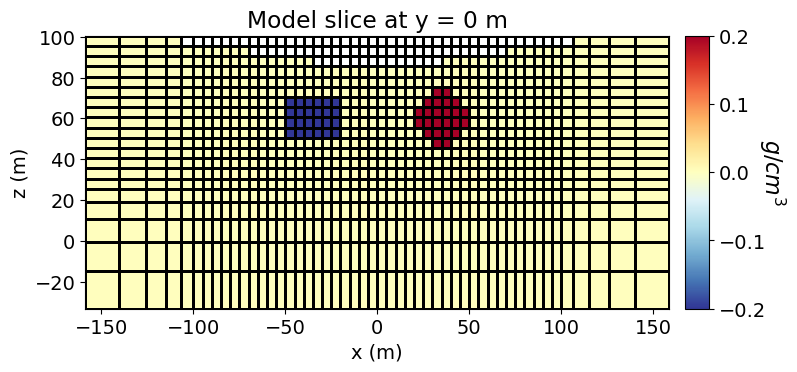

In [10]:
# Map for ignoring inactive cells when plotting
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

# Plot Density Contrast Model
fig = plt.figure(figsize=(8, 3.5))

ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])
mesh.plot_slice(
    plotting_map * model, #将模型映射到网格进行绘制
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(model), np.max(model)),
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
norm = mpl.colors.Normalize(vmin=np.min(model), vmax=np.max(model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=16)

plt.show()

## Forward Simulation

In [11]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

dpred = simulation.dpred(model)

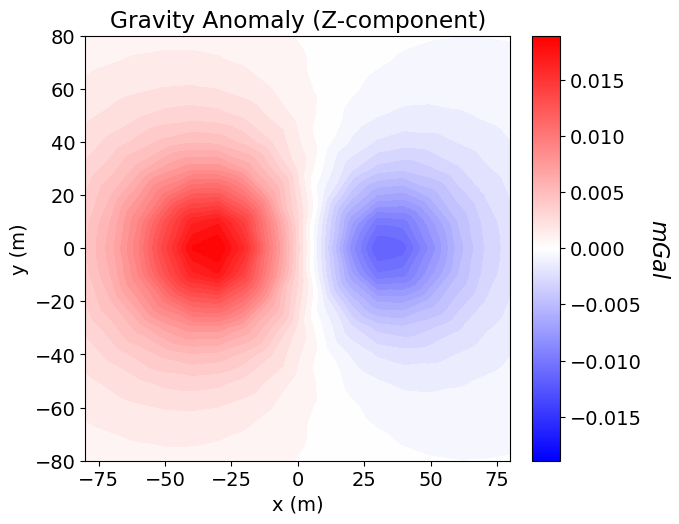

In [12]:
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dpred)), vmax=np.max(np.abs(dpred)))
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Gravity Anomaly (Z-component)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$mGal$", rotation=270, labelpad=20, size=16)

plt.show()

In [ ]:
# if save_output:
#     dir_path = os.path.sep.join([".", "fwd_gravity_anomaly_3d_outputs"]) + os.path.sep
#     if not os.path.exists(dir_path):
#         os.mkdir(dir_path)

#     fname = dir_path + "gravity_topo.txt"
#     np.savetxt(fname, np.c_[topo_xyz], fmt="%.4e")

#     rng = np.random.default_rng(seed=737)
#     maximum_anomaly = np.max(np.abs(dpred))
#     noise = rng.normal(scale=0.02 * maximum_anomaly, size=len(dpred))
#     fname = dir_path + "gravity_data.obs"
#     np.savetxt(fname, np.c_[receiver_locations, dpred + noise], fmt="%.4e")